In [1]:
from typing import List

import modules.data_reader as dr
from modules.common import TimeSeries, TimeSeriesPlot
from modules.time_series_pipeline import TimeSeriesPipeline

In [2]:
params: dr.InputParams = dr.InputParams(
    #reading
    data_directory='data/source_data',
    tickets_group='NDXT_1',
    file_extension='csv',
    time_column='date',
    data_columns=['open', 'close'],
    # processing
    missing_method='rolling',
    rolling_window_size=2,
    target_frequency='H',
    frequency_method='mean',
    anomaly_method='rolling',
    z_threshold=3.0,
    decompose_model='additive',
    decompose_period=24 * 7 * 4,  # дискретизация тренда по месяцам при условии наличия часовых наблюдений
    correlation_method='spearman',
    correlation_threshold=0.3,
    is_feature_selection=True,
    # generating
    cv_method='expanding',
    cv_frequency='M',
    models_types=['linear_regression', 'xgb_regressor'],
    validation_ratio=0.8,
    n_estimators=500,
    max_depth=[2,4,8],
    learning_rate=0.1,
    eval_metric='mae',
    early_stopping_rounds=20
)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.0s


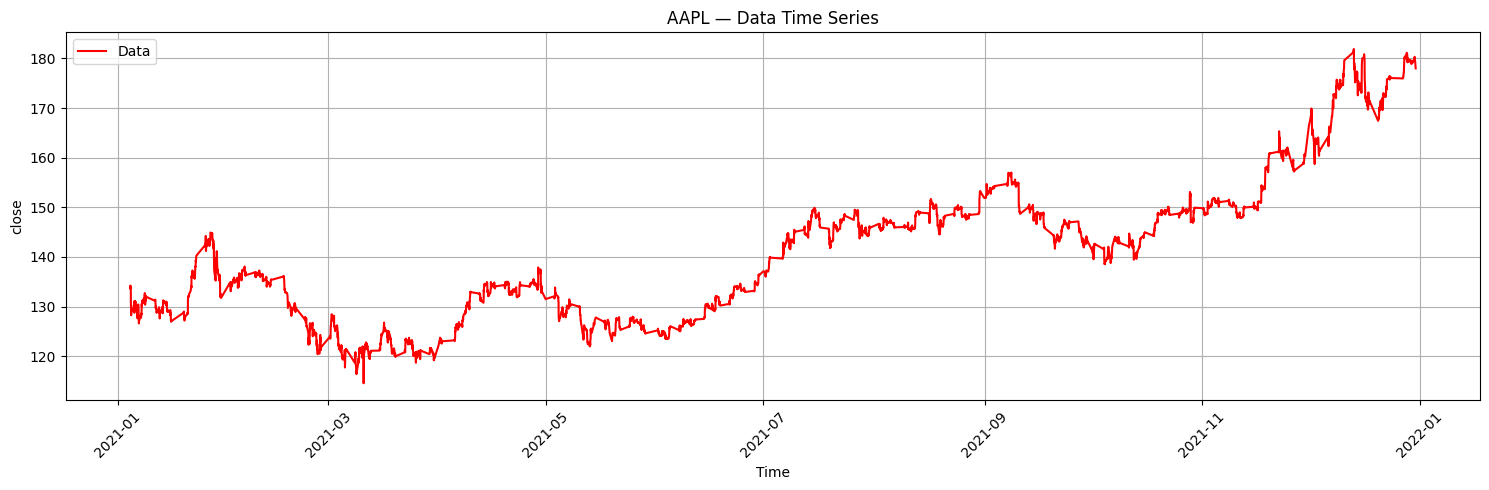

In [3]:
# Инициализация временных рядов
time_series: List[TimeSeries] = (
    TimeSeriesPipeline.time_series_read_parallel(params=params)
)
for ts in time_series:
    if ts.ticket_name == 'AAPL' and ts.data_column_name == 'close':
        TimeSeriesPlot.plot_source_data(time_series=ts)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   2 | elapsed:    0.5s finished


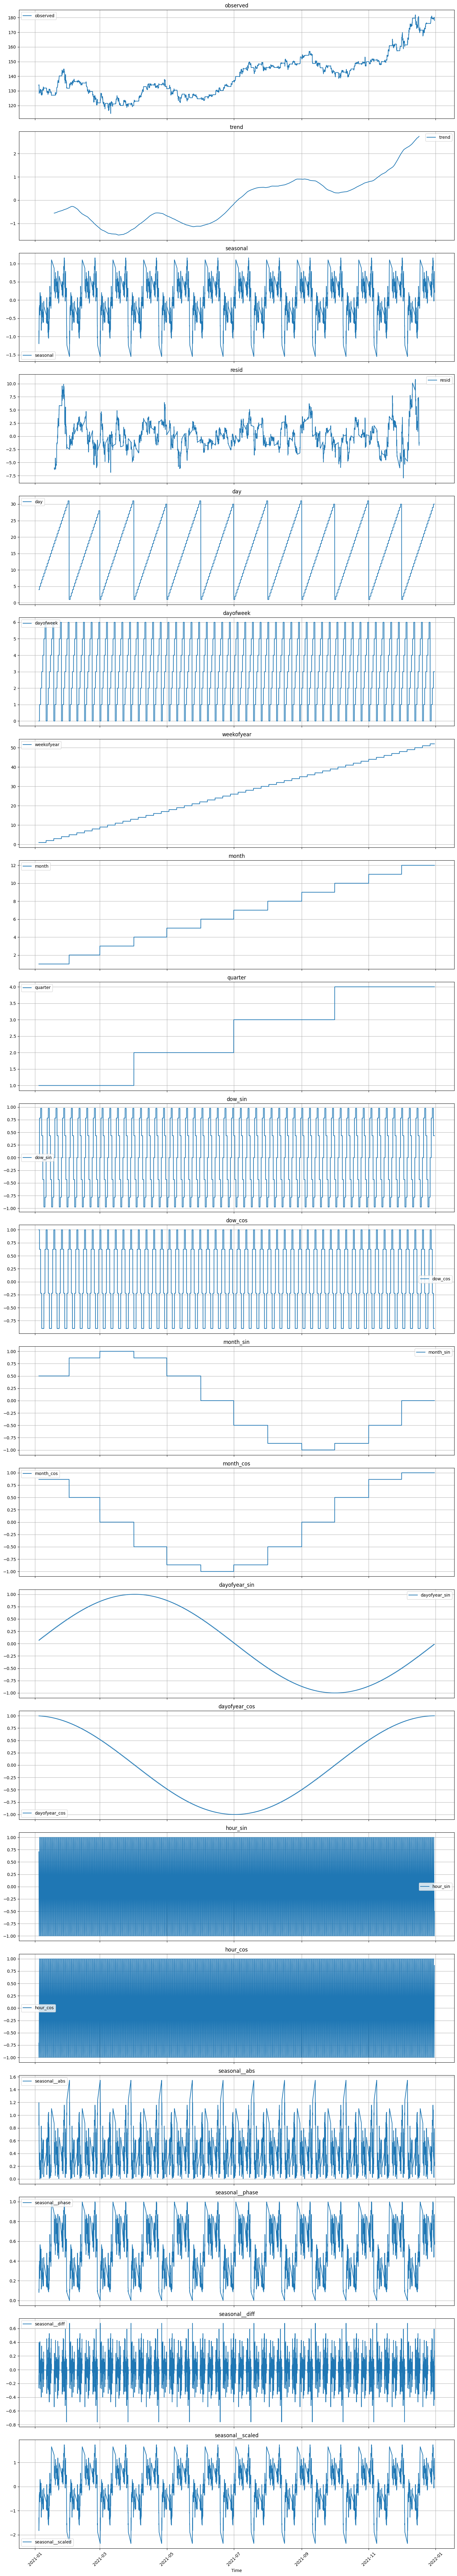

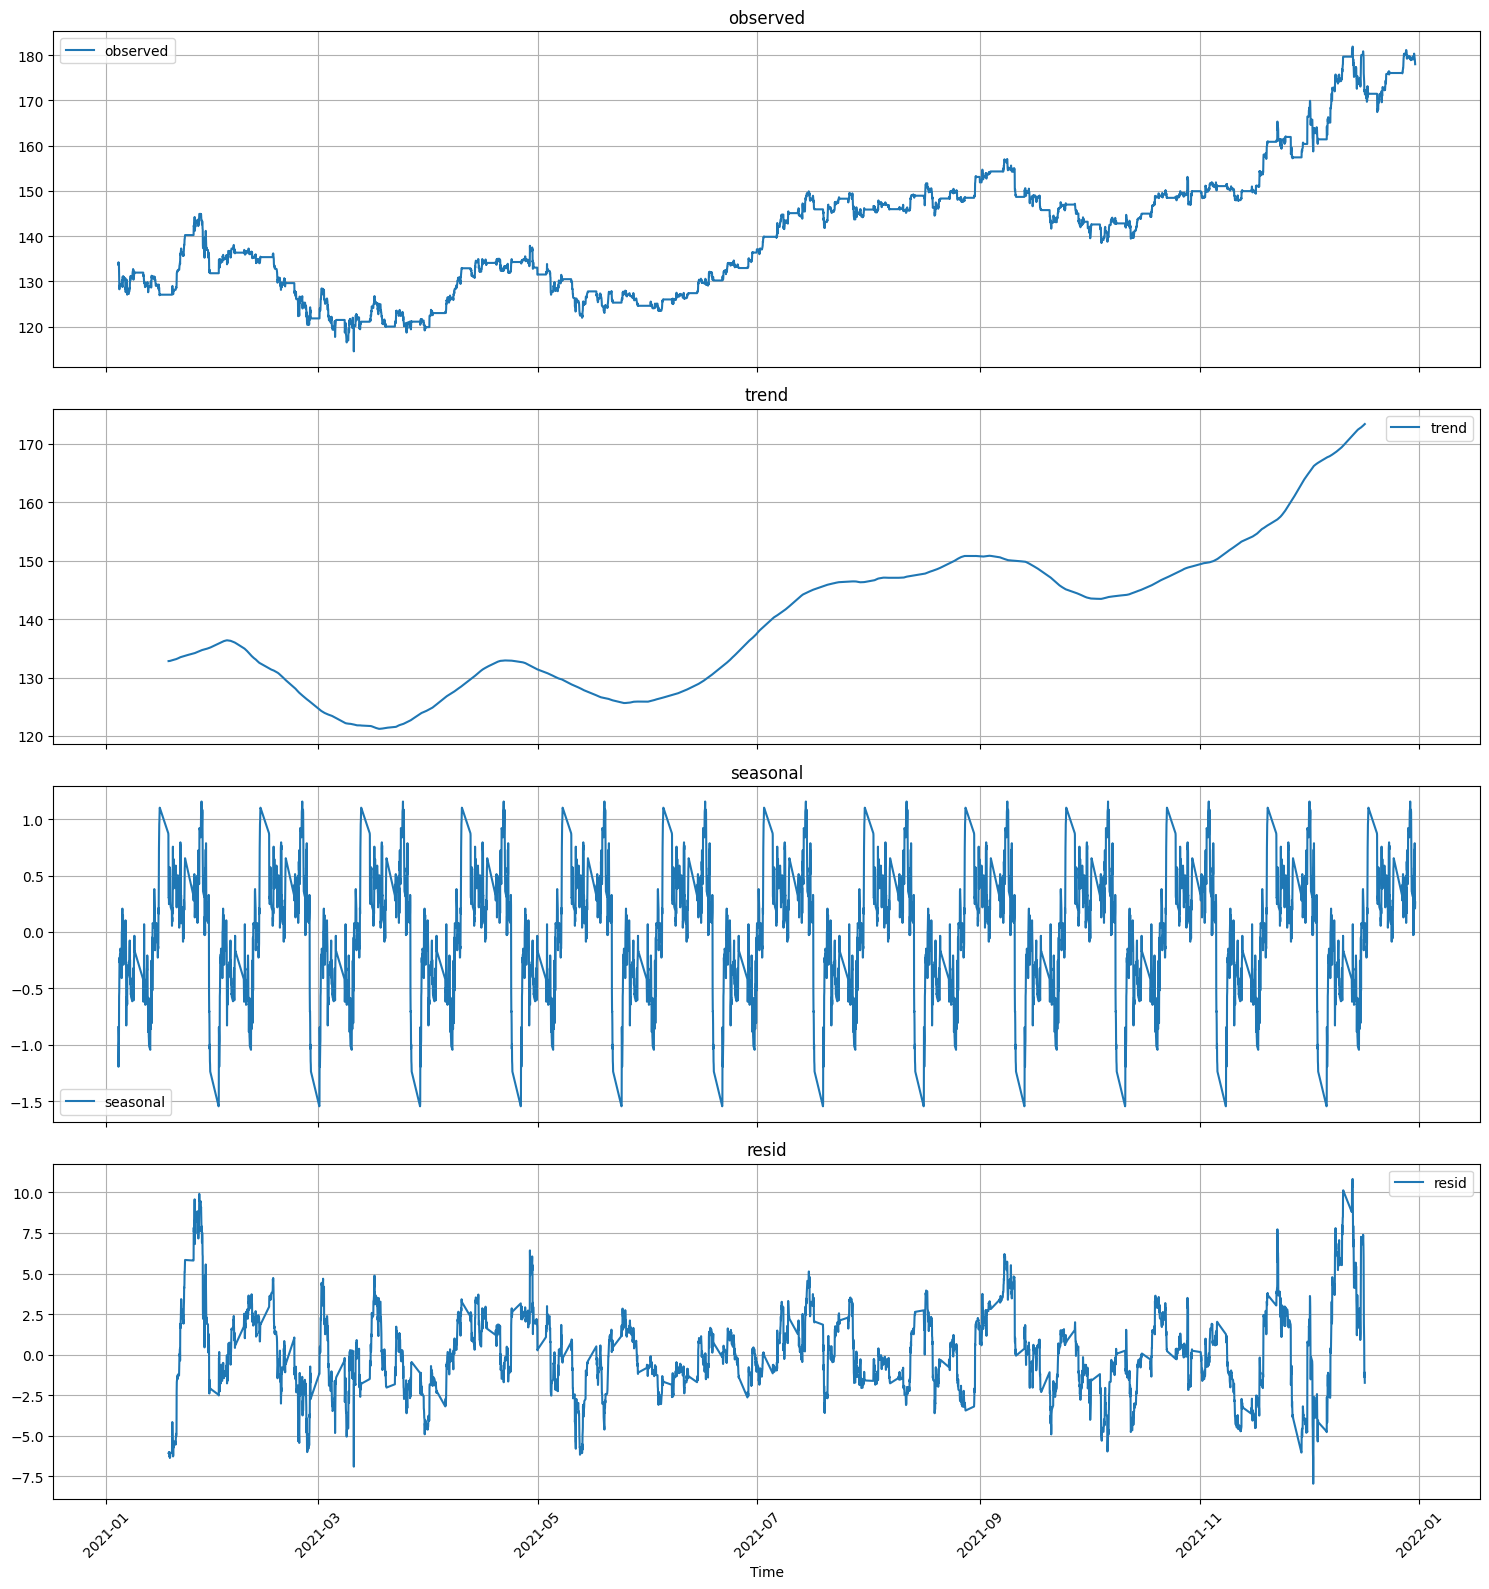

In [4]:
# Подготовка данных временных рядов
time_series_process: List[TimeSeries] = (
    TimeSeriesPipeline.time_series_process_parallel(params=params, time_series=time_series)
)
for ts in time_series_process:
    if ts.ticket_name == 'AAPL' and ts.data_column_name == 'close':
        TimeSeriesPlot.plot_processed_data(time_series=ts)
        TimeSeriesPlot.plot_decomposed_data(time_series=ts)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   2 | elapsed:   31.7s finished


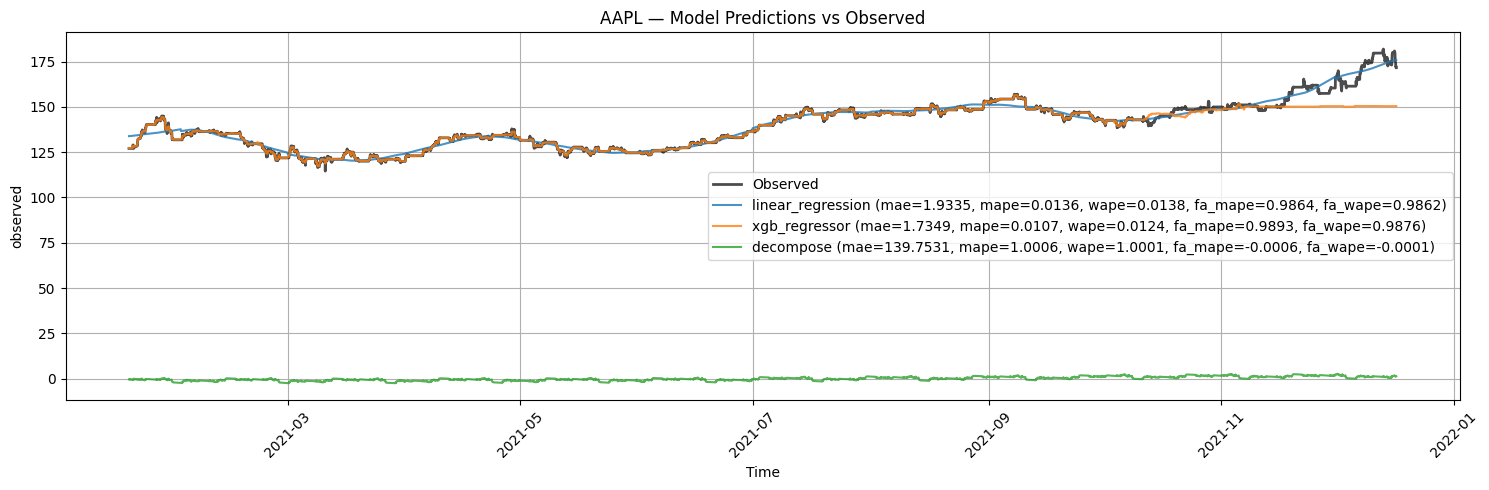

In [5]:
# Генерация моделей для каждого временного ряда
time_series_models: List[TimeSeries] = (
    TimeSeriesPipeline.model_generate_parallel(params=params, time_series=time_series_process)
)
for ts in time_series_models:
    if ts.ticket_name == 'AAPL' and ts.data_column_name == 'close':
        TimeSeriesPlot.plot_processed_prediction_data(time_series=ts)

In [6]:
# Валидация на актуальных данных
params_validate: dr.InputParams = dr.InputParams(
    #reading
    data_directory='data/validate_data',
    tickets_group='NDXT_1',
    file_extension='csv',
    time_column='date',
    data_columns=['open', 'close'],
    # processing
    missing_method='rolling',
    rolling_window_size=2,
    target_frequency='H',
    frequency_method='mean',
    anomaly_method='rolling',
    z_threshold=3.0,
    decompose_model='additive',
    decompose_period=24 * 7 * 4,  # дискретизация тренда по месяцам при условии наличия часовых наблюдений
    correlation_method='spearman',
    correlation_threshold=0.3,
    is_feature_selection=True,
)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   2 | elapsed:    0.5s finished


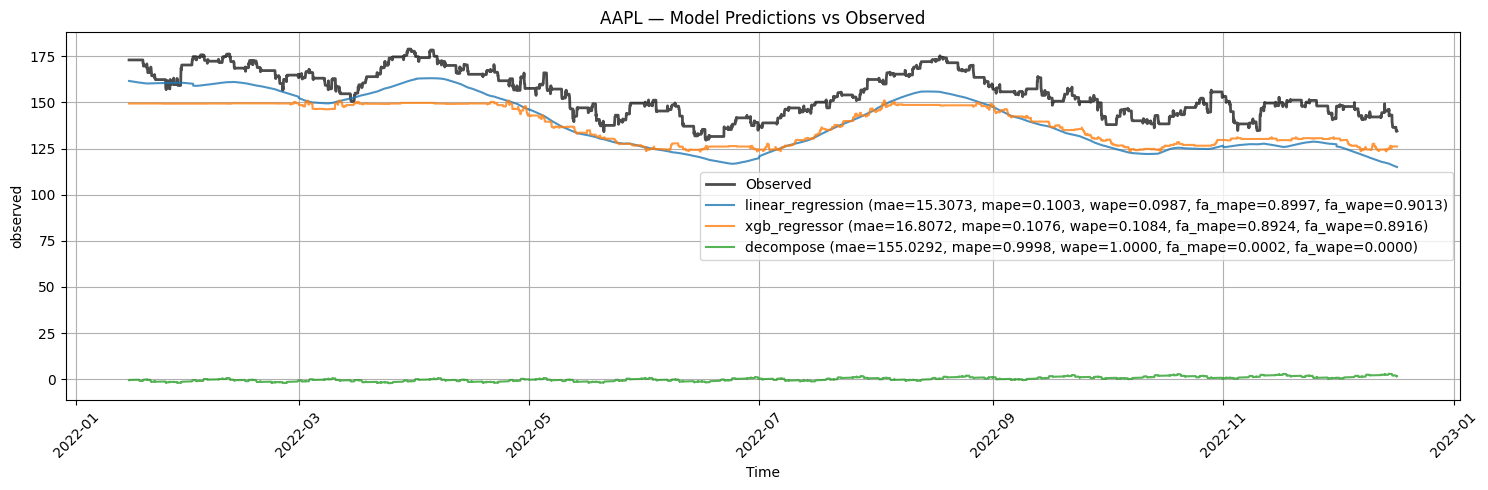

In [7]:
# Инициализация временных рядов
time_series_validate: List[TimeSeries] = TimeSeriesPipeline.time_series_read_parallel(params=params_validate)
# Подготовка данных временных рядов
time_series_process_validate: List[TimeSeries] = (
    TimeSeriesPipeline.time_series_process_parallel(params=params_validate, time_series=time_series_validate)
)
ts_validate = None
for ts in time_series_process_validate:
    if ts.ticket_name == 'AAPL' and ts.data_column_name == 'close':
        ts_validate = ts
for ts in time_series_models:
    if ts.ticket_name == 'AAPL' and ts.data_column_name == 'close':
        TimeSeriesPlot.plot_validate_data(time_series=ts, time_series_validate=ts_validate)